In [1]:
!pip install transformers datasets accelerate mlflow onnxruntime seaborn scikit-learn sentencepiece


In [8]:
import os
import pandas as pd
import numpy as np
import torch
from datasets import DatasetDict, Dataset
from sklearn.model_selection import train_test_split
import mlflow
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
import evaluate
set_seed(42)

os.environ["WANDB_DISABLED"] = "true"

In [9]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

# Merge if needed
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Clean label column
full_df["label"] = full_df["label"].astype(str).str.strip().str.lower()

# -----------------------
# 3-class label mapping
# -----------------------
label_map = {
    "0": 0, "1": 1, "2": 2,
    "negative": 0,
    "neutral": 1,
    "positive": 2,
    "neg": 0, "neu": 1, "pos": 2
}

full_df["label"] = full_df["label"].map(label_map)
full_df = full_df.dropna(subset=["label"])
full_df["label"] = full_df["label"].astype(int)

print("Labels present:", full_df["label"].unique())
print("Total rows:", len(full_df))

Labels present: [2 1 0]
Total rows: 7985


In [10]:
train_df, val_df = train_test_split(
    full_df, test_size=0.2, stratify=full_df["label"], random_state=42
)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df)
})

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6388
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1597
    })
})

In [11]:
MODEL_NAME = "Shushant/nepaliBERT"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Clean text
dataset = dataset.map(lambda x: {"text": str(x["text"])})
dataset = dataset.filter(lambda x: x["text"].strip() != "")

# Tokenize
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=False, max_length=MAX_LEN)

tokenized_dataset = dataset.map(tokenize, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3-class id/label mapping
id2label = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
label2id = {"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


Map:   0%|          | 0/6388 [00:00<?, ? examples/s]

Map:   0%|          | 0/1597 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6388 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1597 [00:00<?, ? examples/s]

Map:   0%|          | 0/6388 [00:00<?, ? examples/s]

Map:   0%|          | 0/1597 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Shushant/nepaliBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

training_args = TrainingArguments(
    output_dir="./nepaliBERT_3class_output",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=20
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

trainer.train()


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2814159400.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.650200,0.677363,0.718222,0.692534
2,0.502400,0.680316,0.740764,0.710147
3,0.338500,0.732730,0.747652,0.719025


TrainOutput(global_step=1200, training_loss=0.5491941440105438, metrics={'train_runtime': 314.9662, 'train_samples_per_second': 60.845, 'train_steps_per_second': 3.81, 'total_flos': 822451432346208.0, 'train_loss': 0.5491941440105438, 'epoch': 3.0})

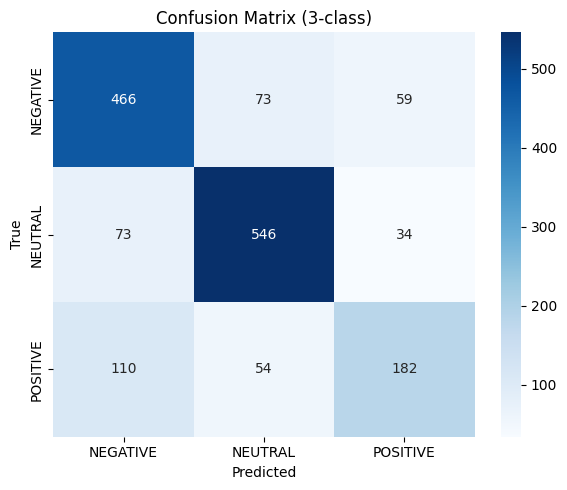


Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.72      0.78      0.75       598
     NEUTRAL       0.81      0.84      0.82       653
    POSITIVE       0.66      0.53      0.59       346

    accuracy                           0.75      1597
   macro avg       0.73      0.71      0.72      1597
weighted avg       0.74      0.75      0.74      1597



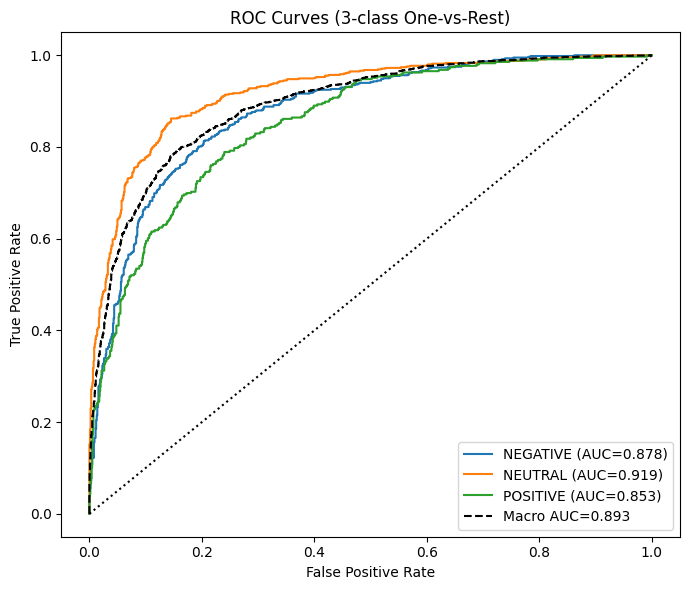

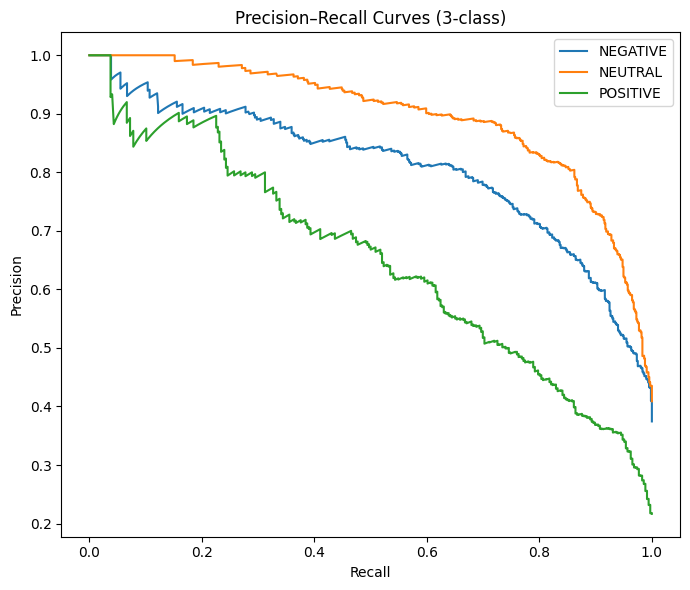

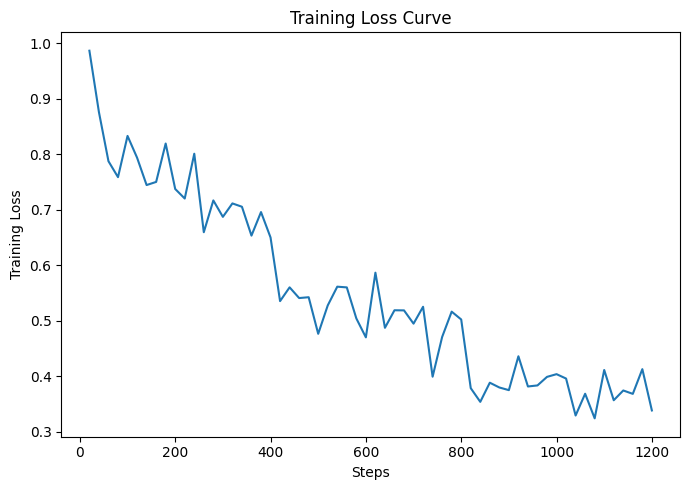

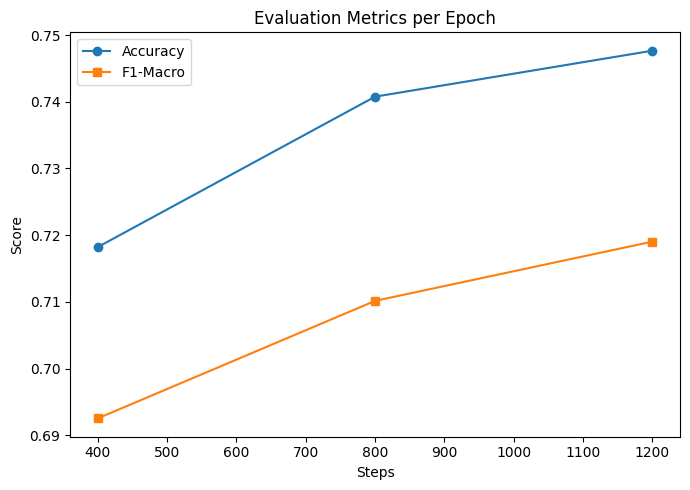

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, classification_report
)
import numpy as np
import torch

# -------------------------
# Load predictions
# -------------------------
pred_output = trainer.predict(tokenized_dataset["validation"])
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)
probs = torch.softmax(torch.tensor(pred_output.predictions), dim=1).numpy()

# -------------------------
# Confusion Matrix
# -------------------------
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=id2label.values(),
            yticklabels=id2label.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (3-class)")
plt.tight_layout()
plt.show()

# -------------------------
# Classification Report
# -------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=id2label.values()))

# -------------------------
# ROC Curves (One-vs-Rest)
# -------------------------
plt.figure(figsize=(7, 6))
for i, label in id2label.items():
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

# Macro ROC
fpr, tpr, _ = roc_curve(
    np.eye(3)[y_true].ravel(),
    probs.ravel()
)
macro_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, 'k--', label=f"Macro AUC={macro_auc:.3f}")

plt.plot([0, 1], [0, 1], 'k:')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (3-class One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Precision-Recall Curves (One-vs-Rest)
# -------------------------
plt.figure(figsize=(7, 6))
for i, label in id2label.items():
    precision, recall, _ = precision_recall_curve((y_true == i).astype(int), probs[:, i])
    plt.plot(recall, precision, label=f"{label}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (3-class)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Training Curves (Loss)
# -------------------------
train_loss = trainer.state.log_history
steps = []
losses = []

for event in train_loss:
    if "loss" in event:
        steps.append(event["step"])
        losses.append(event["loss"])

plt.figure(figsize=(7, 5))
plt.plot(steps, losses)
plt.xlabel("Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.tight_layout()
plt.show()

# -------------------------
# Evaluation Metrics per Epoch
# -------------------------
eval_steps = []
eval_acc = []
eval_f1 = []

for event in train_loss:
    if "eval_accuracy" in event:
        eval_steps.append(event["step"])
        eval_acc.append(event["eval_accuracy"])
        eval_f1.append(event["eval_f1_macro"])

plt.figure(figsize=(7, 5))
plt.plot(eval_steps, eval_acc, marker='o', label="Accuracy")
plt.plot(eval_steps, eval_f1, marker='s', label="F1-Macro")
plt.xlabel("Steps")
plt.ylabel("Score")
plt.title("Evaluation Metrics per Epoch")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
import torch

device = torch.device("cpu")
model.to(device)

onnx_path = "nepaliBERT_3class.onnx"

dummy_input = (
    torch.randint(0, tokenizer.vocab_size, (1, 128), dtype=torch.long).to(device),
    torch.ones((1, 128), dtype=torch.long).to(device)
)

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch"},
        "attention_mask": {0: "batch"},
        "logits": {0: "batch"}
    },
    opset_version=14,
    do_constant_folding=True
)

print("ONNX model exported successfully to:", onnx_path)


/tmp/ipython-input-312567855.py:13: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause th

ONNX model exported successfully to: nepaliBERT_3class.onnx


In [17]:
import shutil

folder_path = "/content/final_nepaliBERT_3class_model"
zip_path = "/content/final_nepaliBERT_3class_model.zip"

shutil.make_archive(zip_path.replace(".zip", ""), 'zip', folder_path)

print("ZIP file created:", zip_path)


ZIP file created: /content/final_nepaliBERT_3class_model.zip


In [18]:
from google.colab import files
files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>